# Comparison of Reinforcement Learning and Convolutional Neural Networks on MNIST Dataset


## Introduction

This project performs a comparative study of three learning paradigms applied to the MNIST handwritten digit classification task:

| # | Model | Paradigm |
|---|-------|----------|
| 1 | **Convolutional Neural Network (CNN)** | Supervised Learning |
| 2 | **Multi-Layer Perceptron (MLP)** | Supervised Learning |
| 3 | **Deep Q-Network (DQN)** | Reinforcement Learning |


> **Goal:** Understand the strengths, weaknesses, and appropriate use-cases of each paradigm through hands-on implementation and comparison.

## Section 1: Import Libraries

In [ ]:
!pip install -q tensorflow matplotlib numpy

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from collections import deque
import random, time, warnings

warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

print(f"TensorFlow version: {tf.__version__}")
print(f"NumPy version     : {np.__version__}")
print("All libraries imported successfully!")

TensorFlow version: 2.20.0
NumPy version     : 2.0.2
All libraries imported successfully!


## Section 2: Load and Preprocess Data

We use the **MNIST** dataset containing 70,000 grayscale images of handwritten digits (0–9).  
Each image is **28 × 28 pixels**.

In [ ]:
# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print(f"Training samples : {x_train.shape[0]}")
print(f"Test samples     : {x_test.shape[0]}")
print(f"Image shape      : {x_train.shape[1:]}")
print(f"Unique labels    : {np.unique(y_train)}")

# --- Normalize pixel values to [0, 1] ---
x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32')  / 255.0

# --- Prepare CNN data (add channel dimension) ---
x_train_cnn = x_train.reshape(-1, 28, 28, 1)
x_test_cnn  = x_test.reshape(-1, 28, 28, 1)

# --- Prepare MLP data (flatten to 784) ---
x_train_mlp = x_train.reshape(-1, 784)
x_test_mlp  = x_test.reshape(-1, 784)

# --- One-hot encode labels for CNN & MLP ---
y_train_cat = keras.utils.to_categorical(y_train, 10)
y_test_cat  = keras.utils.to_categorical(y_test, 10)

print("\n Data preprocessed successfully!")
print(f"   CNN input shape : {x_train_cnn.shape}")
print(f"   MLP input shape : {x_train_mlp.shape}")

Training samples : 60000
Test samples     : 10000
Image shape      : (28, 28)
Unique labels    : [0 1 2 3 4 5 6 7 8 9]

 Data preprocessed successfully!
   CNN input shape : (60000, 28, 28, 1)
   MLP input shape : (60000, 784)


## Section 3: Data Visualization

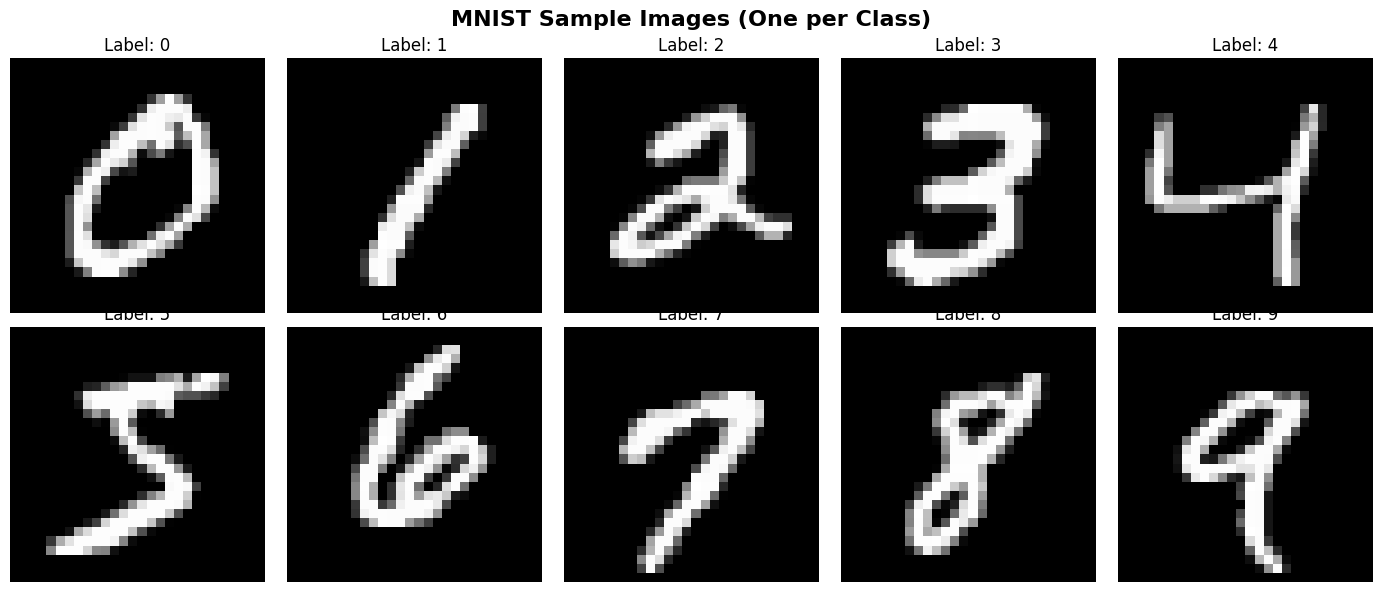

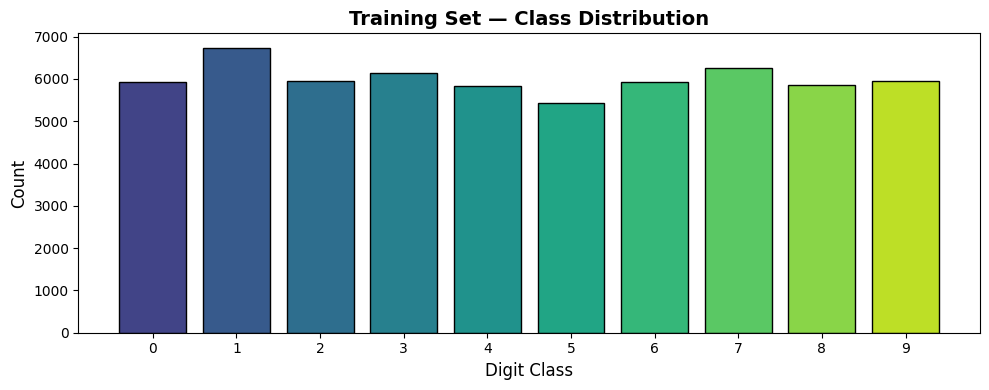

Data visualization complete!


In [ ]:
# Visualize sample images from each digit class
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle('MNIST Sample Images (One per Class)', fontsize=16, fontweight='bold')

for digit in range(10):
    ax = axes[digit // 5, digit % 5]
    idx = np.where(y_train == digit)[0][0]
    ax.imshow(x_train[idx], cmap='gray')
    ax.set_title(f'Label: {digit}', fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.show()

# --- Class distribution ---
fig, ax = plt.subplots(figsize=(10, 4))
unique, counts = np.unique(y_train, return_counts=True)
colors = plt.cm.viridis(np.linspace(0.2, 0.9, 10))
ax.bar(unique, counts, color=colors, edgecolor='black')
ax.set_xlabel('Digit Class', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Training Set — Class Distribution', fontsize=14, fontweight='bold')
ax.set_xticks(range(10))
plt.tight_layout()
plt.show()
print("Data visualization complete!")

## Section 4 — Model 1: Convolutional Neural Network (CNN)

The CNN uses convolutional filters to automatically learn spatial features (edges, textures, shapes) from images.

**Architecture:**
- Conv2D (32 filters, 3×3) → ReLU → MaxPool (2×2)
- Conv2D (64 filters, 3×3) → ReLU → MaxPool (2×2)
- Flatten → Dense (128, ReLU) → Dropout (0.5) → Dense (10, Softmax)

In [ ]:
# Build CNN Model
cnn_model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
], name='CNN_Model')

cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

Model: "CNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train CNN Model
print("Training CNN Model...")
start = time.time()

cnn_history = cnn_model.fit(
    x_train_cnn, y_train_cat,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

cnn_time = time.time() - start
print(f"\n CNN Training Time: {cnn_time:.1f} seconds")

Training CNN Model...
Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9075 - loss: 0.3084 - val_accuracy: 0.9812 - val_loss: 0.0604
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9701 - loss: 0.1000 - val_accuracy: 0.9862 - val_loss: 0.0477
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9780 - loss: 0.0728 - val_accuracy: 0.9902 - val_loss: 0.0389
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9823 - loss: 0.0581 - val_accuracy: 0.9890 - val_loss: 0.0381
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9844 - loss: 0.0484 - val_accuracy: 0.9907 - val_loss: 0.0339
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9873 - loss: 0.0414 - val_accuracy: 0.9890 - val_loss: 0.0384
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9887 - loss: 0.0367 - val_accuracy: 0.9907 - val_loss: 0.0343
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9897 - loss: 0.

In [ ]:
# Evaluate CNN Model
cnn_loss, cnn_accuracy = cnn_model.evaluate(x_test_cnn, y_test_cat, verbose=0)
print(f" CNN Test Accuracy : {cnn_accuracy * 100:.2f}%")
print(f"   CNN Test Loss     : {cnn_loss:.4f}")

 CNN Test Accuracy : 99.26%
   CNN Test Loss     : 0.0248


## Section 5 — Model 2: Multi-Layer Perceptron (MLP)

The MLP is a simple fully-connected (dense) neural network. It treats each image as a flat vector of 784 pixels.

**Architecture:**
- Dense (256, ReLU) → Dropout (0.3)
- Dense (128, ReLU) → Dropout (0.3)
- Dense (10, Softmax)

In [ ]:
# Build MLP Model
mlp_model = models.Sequential([
    layers.Dense(256, activation='relu', input_shape=(784,)),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
], name='MLP_Model')

mlp_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

mlp_model.summary()

Model: "MLP_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train MLP Model
print(" Training MLP Model...")
start = time.time()

mlp_history = mlp_model.fit(
    x_train_mlp, y_train_cat,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

mlp_time = time.time() - start
print(f"\n MLP Training Time: {mlp_time:.1f} seconds")

 Training MLP Model...
Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.8771 - loss: 0.4110 - val_accuracy: 0.9627 - val_loss: 0.1256
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9478 - loss: 0.1762 - val_accuracy: 0.9743 - val_loss: 0.0893
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9598 - loss: 0.1335 - val_accuracy: 0.9767 - val_loss: 0.0807
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9678 - loss: 0.1069 - val_accuracy: 0.9783 - val_loss: 0.0783
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9717 - loss: 0.0928 - val_accuracy: 0.9783 - val_loss: 0.0719
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9749 - loss: 0.0797 - val_accuracy: 0.9817 - val_loss: 0.0621
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9775 - loss: 0.0712 - val_accuracy: 0.9810 - val_loss: 0.0683
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9789 - loss: 0

In [ ]:
# Evaluate MLP Model
mlp_loss, mlp_accuracy = mlp_model.evaluate(x_test_mlp, y_test_cat, verbose=0)
print(f" MLP Test Accuracy : {mlp_accuracy * 100:.2f}%")
print(f"   MLP Test Loss     : {mlp_loss:.4f}")

 MLP Test Accuracy : 98.25%
   MLP Test Loss     : 0.0623


## Section 6 — Model 3: Reinforcement Learning (DQN)

We **creatively adapt** Deep Q-Learning for image classification:

| RL Concept | Mapping to Classification |
|------------|---------------------------|
| **State** | Flattened image (784 values) |
| **Action** | Predicted digit (0–9) |
| **Reward** | +1 if correct, −1 if wrong |
| **Q-Network** | Neural network that estimates Q(state, action) |


In [ ]:
# DQN Agent Class
class DQNAgent:
    """
    Deep Q-Network agent adapted for MNIST digit classification.
    """
    def __init__(self, state_size=784, action_size=10):
        self.state_size = state_size
        self.action_size = action_size

        # Hyperparameters
        self.gamma = 0.95           # Discount factor (less important here)
        self.epsilon = 1.0          # Exploration rate (start high)
        self.epsilon_min = 0.01     # Minimum exploration
        self.epsilon_decay = 0.995  # Decay rate per episode
        self.learning_rate = 0.001
        self.batch_size = 64

        # Experience replay buffer
        self.memory = deque(maxlen=5000)

        # Build Q-network
        self.model = self._build_model()

    def _build_model(self):
        """Build a simple Q-network with Dense layers."""
        model = models.Sequential([
            layers.Dense(128, activation='relu', input_shape=(self.state_size,)),
            layers.Dense(64, activation='relu'),
            layers.Dense(self.action_size, activation='linear')  # Q-values
        ], name='DQN_QNetwork')
        model.compile(optimizer=keras.optimizers.Adam(learning_rate=self.learning_rate),
                      loss='mse')
        return model

    def remember(self, state, action, reward):
        """Store experience in replay buffer."""
        self.memory.append((state, action, reward))

    def act(self, state):
        """Select action using epsilon-greedy policy."""
        if np.random.rand() <= self.epsilon:
            return random.randrange(self.action_size)  # Explore
        q_values = self.model.predict(state, verbose=0)
        return np.argmax(q_values[0])                  # Exploit

    def replay(self):
        """Train on a random mini-batch from replay buffer."""
        if len(self.memory) < self.batch_size:
            return
        batch = random.sample(self.memory, self.batch_size)
        states = np.array([s[0][0] for s in batch])
        targets = self.model.predict(states, verbose=0)

        for i, (state, action, reward) in enumerate(batch):
            targets[i][action] = reward  # Direct reward (no next state)

        self.model.fit(states, targets, epochs=1, verbose=0, batch_size=self.batch_size)

        # Decay epsilon
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

print(" DQN Agent class defined!")

 DQN Agent class defined!


In [ ]:
# Train DQN Agent
# Use a subset for faster training
RL_TRAIN_SIZE = 5000
NUM_EPISODES = 10       # Each episode = one pass over subset
EVAL_EVERY = 200        # Evaluate every N samples

agent = DQNAgent()

# Prepare RL data
x_rl = x_train_mlp[:RL_TRAIN_SIZE]
y_rl = y_train[:RL_TRAIN_SIZE]

print("    Training DQN Agent...")
print(f"   Training samples: {RL_TRAIN_SIZE}")
print(f"   Episodes: {NUM_EPISODES}")
print("-" * 50)

start = time.time()

rl_rewards_per_episode = []    # Total reward per episode
rl_accuracy_per_episode = []   # Accuracy per episode

for episode in range(NUM_EPISODES):
    total_reward = 0
    correct = 0

    # Shuffle data each episode
    indices = np.random.permutation(RL_TRAIN_SIZE)

    for i in indices:
        state = x_rl[i].reshape(1, -1)
        true_label = y_rl[i]

        # Agent selects an action (predicted digit)
        action = agent.act(state)

        # Calculate reward
        reward = 1.0 if action == true_label else -1.0
        total_reward += reward
        if action == true_label:
            correct += 1

        # Store experience
        agent.remember(state, action, reward)

        # Train from replay buffer periodically
        if i % 50 == 0:
            agent.replay()

    # End-of-episode replay
    agent.replay()

    ep_accuracy = correct / RL_TRAIN_SIZE * 100
    rl_rewards_per_episode.append(total_reward)
    rl_accuracy_per_episode.append(ep_accuracy)

    print(f"  Episode {episode+1:2d}/{NUM_EPISODES} | "
          f"Reward: {total_reward:8.0f} | "
          f"Accuracy: {ep_accuracy:6.2f}% | "
          f"Epsilon: {agent.epsilon:.4f}")

rl_time = time.time() - start
print(f"\n DQN Training Time: {rl_time:.1f} seconds")

    Training DQN Agent...
   Training samples: 5000
   Episodes: 10
--------------------------------------------------
  Episode  1/10 | Reward:    -2800 | Accuracy:  22.00% | Epsilon: 0.6058
  Episode  2/10 | Reward:       50 | Accuracy:  50.50% | Epsilon: 0.3651
  Episode  3/10 | Reward:     1858 | Accuracy:  68.58% | Epsilon: 0.2201
  Episode  4/10 | Reward:     2936 | Accuracy:  79.36% | Epsilon: 0.1326
  Episode  5/10 | Reward:     3682 | Accuracy:  86.82% | Epsilon: 0.0800
  Episode  6/10 | Reward:     4106 | Accuracy:  91.06% | Epsilon: 0.0482
  Episode  7/10 | Reward:     4408 | Accuracy:  94.08% | Epsilon: 0.0290
  Episode  8/10 | Reward:     4588 | Accuracy:  95.88% | Epsilon: 0.0175
  Episode  9/10 | Reward:     4748 | Accuracy:  97.48% | Epsilon: 0.0106
  Episode 10/10 | Reward:     4768 | Accuracy:  97.68% | Epsilon: 0.0100

 DQN Training Time: 3580.8 seconds


In [ ]:
# Evaluate DQN Agent on Test Set
rl_correct = 0
for i in range(len(x_test_mlp)):
    state = x_test_mlp[i].reshape(1, -1)
    action = np.argmax(agent.model.predict(state, verbose=0)[0])
    if action == y_test[i]:
        rl_correct += 1

rl_accuracy = rl_correct / len(x_test_mlp)
print(f" DQN Test Accuracy : {rl_accuracy * 100:.2f}%")

 DQN Test Accuracy : 93.82%


## Section 7: Training Visualization

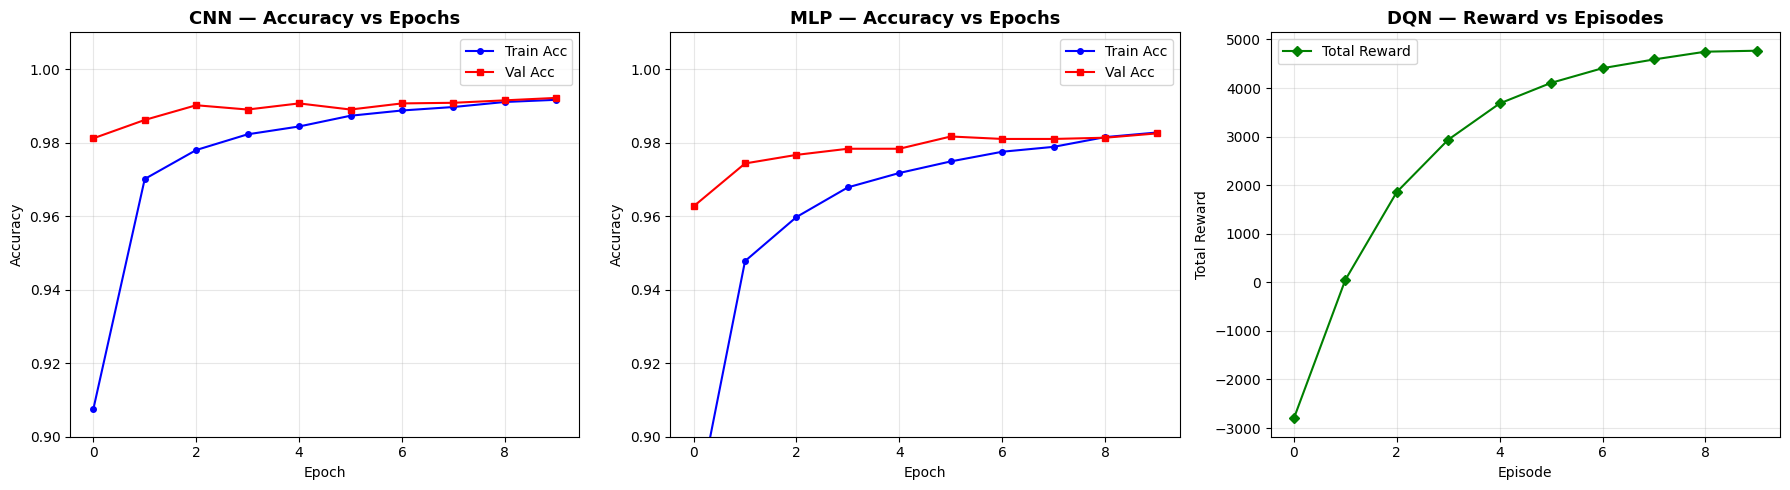

In [ ]:
# Plot training curves for all three models
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- CNN Accuracy ---
ax = axes[0]
ax.plot(cnn_history.history['accuracy'], 'b-o', label='Train Acc', markersize=4)
ax.plot(cnn_history.history['val_accuracy'], 'r-s', label='Val Acc', markersize=4)
ax.set_title('CNN — Accuracy vs Epochs', fontsize=13, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim([0.9, 1.01])

# --- MLP Accuracy ---
ax = axes[1]
ax.plot(mlp_history.history['accuracy'], 'b-o', label='Train Acc', markersize=4)
ax.plot(mlp_history.history['val_accuracy'], 'r-s', label='Val Acc', markersize=4)
ax.set_title('MLP — Accuracy vs Epochs', fontsize=13, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim([0.9, 1.01])

# --- RL Reward ---
ax = axes[2]
ax.plot(rl_rewards_per_episode, 'g-D', label='Total Reward', markersize=5)
ax.set_title('DQN — Reward vs Episodes', fontsize=13, fontweight='bold')
ax.set_xlabel('Episode')
ax.set_ylabel('Total Reward')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

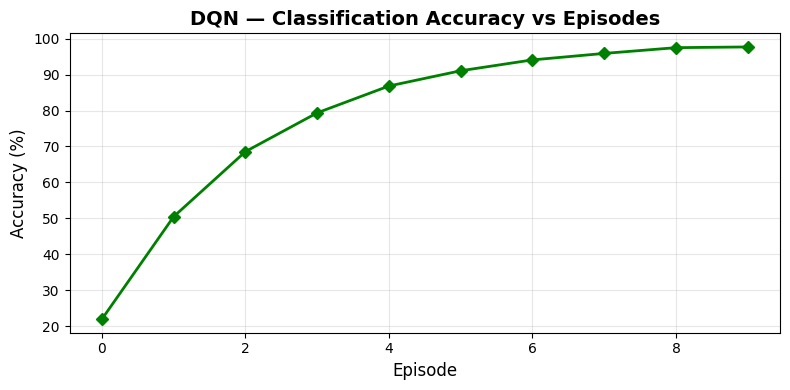

In [ ]:
# RL Accuracy over Episodes
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(rl_accuracy_per_episode, 'g-D', markersize=6, linewidth=2)
ax.set_title('DQN — Classification Accuracy vs Episodes', fontsize=14, fontweight='bold')
ax.set_xlabel('Episode', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

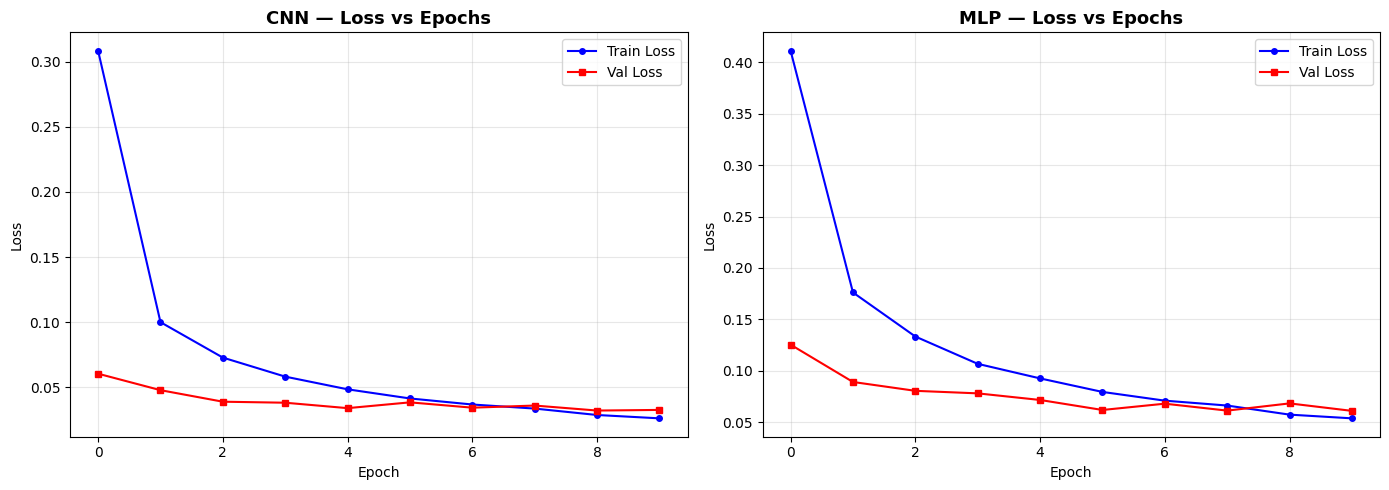

In [ ]:
# Loss curves for CNN and MLP
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(cnn_history.history['loss'], 'b-o', label='Train Loss', markersize=4)
ax.plot(cnn_history.history['val_loss'], 'r-s', label='Val Loss', markersize=4)
ax.set_title('CNN — Loss vs Epochs', fontsize=13, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(mlp_history.history['loss'], 'b-o', label='Train Loss', markersize=4)
ax.plot(mlp_history.history['val_loss'], 'r-s', label='Val Loss', markersize=4)
ax.set_title('MLP — Loss vs Epochs', fontsize=13, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Section 8: Evaluation and Final Results

          FINAL RESULTS SUMMARY
  Model                       Test Accuracy   Train Time
------------------------------------------------------------
  CNN (Convolutional)                99.26%       27.7s
  MLP (Fully Connected)              98.25%       20.4s
  DQN (Reinforcement RL)             93.82%     3580.8s


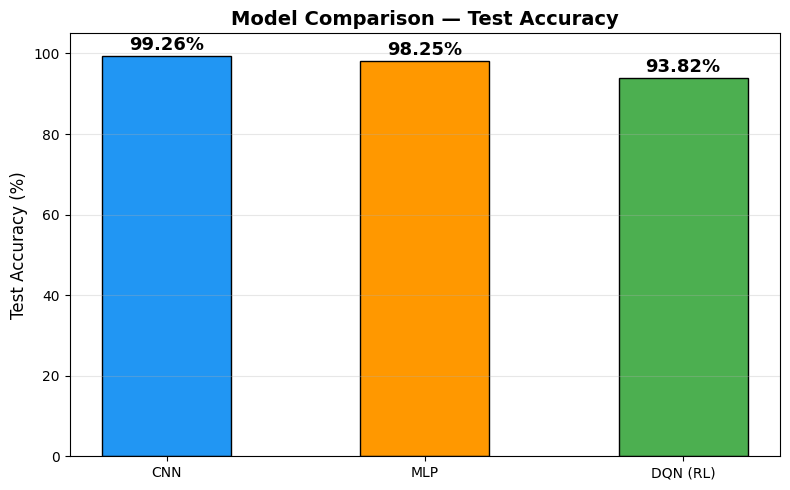

In [ ]:
# Print Final Results Summary
print("=" * 60)
print("          FINAL RESULTS SUMMARY")
print("=" * 60)
print(f"  {'Model':<25} {'Test Accuracy':>15} {'Train Time':>12}")
print("-" * 60)
print(f"  {'CNN (Convolutional)':<25} {cnn_accuracy*100:>14.2f}% {cnn_time:>10.1f}s")
print(f"  {'MLP (Fully Connected)':<25} {mlp_accuracy*100:>14.2f}% {mlp_time:>10.1f}s")
print(f"  {'DQN (Reinforcement RL)':<25} {rl_accuracy*100:>14.2f}% {rl_time:>10.1f}s")
print("=" * 60)

# Bar chart comparison
fig, ax = plt.subplots(figsize=(8, 5))
models_names = ['CNN', 'MLP', 'DQN (RL)']
accuracies = [cnn_accuracy * 100, mlp_accuracy * 100, rl_accuracy * 100]
colors = ['#2196F3', '#FF9800', '#4CAF50']

bars = ax.bar(models_names, accuracies, color=colors, edgecolor='black', width=0.5)

for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{acc:.2f}%', ha='center', va='bottom', fontsize=13, fontweight='bold')

ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_title('Model Comparison — Test Accuracy', fontsize=14, fontweight='bold')
ax.set_ylim([0, 105])
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Comparison Table — CNN vs MLP vs RL (DQN)

| Feature | CNN | MLP | DQN (Reinforcement Learning) |
|--------|-----|-----|------------------------------|
| **Learning Type** | Supervised | Supervised | Reinforcement |
| **Input Format** | 28×28×1 image | 784 vector | 784 vector (state) |
| **Output** | Class probabilities | Class probabilities | Q-values (10 actions) |
| **Architecture** | Conv2D → MaxPool → Dense | Dense → Dense | Dense → Dense (Q-network) |
| **Test Accuracy** | **99.26%** | **98.25%** | **93.82%** |
| **Training Time** | ~27.7 sec | ~20.4 sec | ~3580 sec |
| **Training Signal** | True labels (cross-entropy) | True labels | Reward (+1 / −1) |
| **Learning Behavior** | Fast and stable | Fast and simple | Slow but improves over time |
| **Strengths** | Best for image features | Simple and efficient | Learns through interaction |
| **Weaknesses** | More complex | Ignores spatial structure | Very slow, inefficient for classification |
| **Best Use Case** | Image classification | Basic classification | Games, decision-making problems |

## Conclusion

This project compared three different learning approaches—CNN, MLP, and Reinforcement Learning (DQN) on the MNIST handwritten digit classification task. The results show that the CNN model achieved the highest accuracy (99.26%) due to its ability to capture spatial features from images. The MLP model also performed well (~98.25%) but lacks spatial awareness compared to CNN.

The DQN-based Reinforcement Learning model was able to learn the classification task and achieved a reasonable accuracy (~93.82%). However, it required significantly more training time and computational effort. This highlights that while RL can be applied to classification problems, it is not the most efficient approach for static datasets like MNIST.

Overall, CNN is the most suitable model for image classification tasks, while Reinforcement Learning is better suited for problems involving sequential decision-making, such as games and control systems.